In [1]:
import requests

# pip install beautifulsoup4
from bs4 import BeautifulSoup

# https://www.weather.go.kr/ > 관측기후 > 육상 > 도시별관측
response = requests.get("https://www.weather.go.kr/w/obs-climate/land/city-obs.do")
soup = BeautifulSoup(response.content, 'html.parser')

table = soup.find('table', id='weather_table')

table

data = []
for tr in table.find_all('tr'):
    tds = list(tr.find_all('td'))

    for td in tds:
        if td.find('a'):
            point = td.find('a').text
            temperature = tds[5].text
            humidity = tds[9].text

            data.append([point, temperature, humidity])

data

[['강릉', '30.5', '72'],
 ['강진군', '29.2', '73'],
 ['강화', '26.6', '74'],
 ['거제', '27.0', '70'],
 ['거창', '26.2', '82'],
 ['경주시', '28.9', '74'],
 ['고산', '27.0', '87'],
 ['고창', '25.4', '84'],
 ['고창군', '24.1', '89'],
 ['고흥', '26.0', '90'],
 ['광양시', '29.3', '78'],
 ['광주', '29.9', '81'],
 ['구미', '28.2', '77'],
 ['군산', '28.6', '71'],
 ['금산', '28.9', '72'],
 ['김해시', '28.5', '75'],
 ['남원', '28.9', '71'],
 ['남해', '27.2', '79'],
 ['대관령', '23.3', '86'],
 ['대구', '31.0', '61'],
 ['대전', '29.5', '70'],
 ['동두천', '26.3', '85'],
 ['동해', '25.0', '99'],
 ['목포', '29.7', '73'],
 ['문경', '27.1', '85'],
 ['밀양', '30.6', '50'],
 ['백령도', '25.3', '89'],
 ['보령', '27.4', '76'],
 ['보성군', '28.5', '78'],
 ['보은', '27.7', '83'],
 ['봉화', '24.7', '86'],
 ['부산', '28.7', '66'],
 ['부안', '28.8', '72'],
 ['부여', '27.9', '77'],
 ['북강릉', '27.0', '87'],
 ['북부산', '28.9', '73'],
 ['북창원', '30.2', '66'],
 ['북춘천', '27.1', '87'],
 ['산청', '28.6', '72'],
 ['상주', '29.1', '79'],
 ['서귀포', '28.0', '82'],
 ['서산', '27.9', '79'],
 ['서울', '28.7', '68'

In [2]:
with open('weather.csv', 'w', encoding='UTF8') as file:
    file.write('point, temperature, humidity\n')
    for i in data:
        file.write(f'{i[0]},{i[1]},{i[2]}\n')

In [3]:
# matplotlib.pyplot의 show 함수를 호출하지 않아도 주피터 노트북 안에서 그래프가 표시됨
# %matplotlib inline
import pandas as pd # 데이터 처리

df = pd.read_csv('weather.csv', index_col='point') # csv 파일을 읽어서 DataFrame 객체로 만듦. 인덱스 항목(컬럼)은 point로 설정
df



,temperature,humidity
point,,
강릉,30.5,72
강진군,29.2,73
강화,26.6,74
거제,27.0,70
거창,26.2,82
...,...,...
합천,29.2,76
해남,27.3,87
홍성,28.3,90


In [4]:
# 특별시, 광역시만 모아서 DataFrame 객체로 만듦
# loc 속성은 label-location의 약자로 레이블을 지정해 특정 인덱스의 데이터만 가져오는데 씀
city_df = df.loc[['서울', '인천', '대전', '대구', '광주', '부산', '울산']]
city_df

,temperature,humidity
point,,
서울,28.7,68
인천,28.8,66
대전,29.5,70
대구,31.0,61
광주,29.9,81
부산,28.7,66
울산,28.0,76


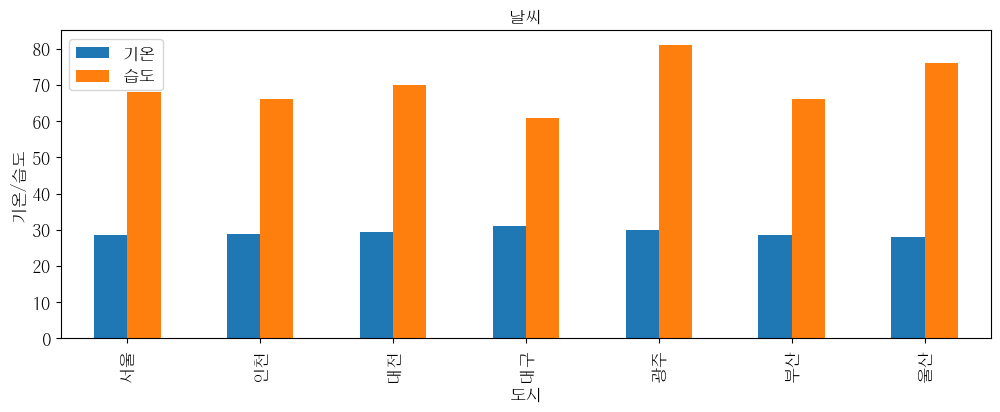

In [8]:
# Windows 한글 폰트 설정
# pip install matplotlib
from matplotlib import font_manager, rc

# AttributeError: module 'matplotlib' has no attribute 'font_manager' 에러가 발생하면 해당 코드를 주석 처리한 후 실행한 후, 주석 해제 후 다시 실행하면 됨
# .get_name() 누락 주의!!!
font_path = 'C:/Windows/Fonts/HYGPRM.TTF'
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

# 차트 종류, 제목, 차트 크기, 범례, 폰트 크기 설정
ax = city_df.plot(kind='bar', title='날씨', figsize=(12, 4), legend=True, fontsize=12)
ax.set_xlabel('도시', fontsize=12)          # x축 정보 표시
ax.set_ylabel('기온/습도', fontsize=12)     # y축 정보 표시
ax.legend(['기온', '습도'], fontsize=12)    # 범례 지정

# import matplotlib.pyplot as plt # IDLE, 파이썬 인터프리터에서 그래프 표시
# plt.show()